In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("cleaned_data.csv")
df.head()

,experience_id,imported_class_year,imported_program,imported_unit,major_department,major_unit,notes,person_id,record_id,registrar_class_year,...,participant_programs_unique,participant_record_id_unique,uniqname,registrar_department.1,registrar_program,registrar_type,registrar_unit.1,term_season,year,student_name
0,182.0,Sophomore,Dance BFA,NaN,Dance,"Music, Theatre & Dance",Credit Hours: 1,415.0,689.0,Sophomore,...,Dance BFA,689.0,abniemi,Dance,Dance BFA,Major,"Music, Theatre & Dance",FA,2019,Abby Niemi
1,182.0,Sophomore,Dance BFA,NaN,Dance,"Music, Theatre & Dance",Credit Hours: 1,415.0,689.0,Sophomore,...,Dance BFA Dance BFA,14905.0,abniemi,Dance,Dance BFA,Major,"Music, Theatre & Dance",FA,2019,Abby Niemi
2,178.0,Sophomore,Theatre BTA,NaN,Theatre & Drama,"Music, Theatre & Dance",Credit Hours: 1,416.0,690.0,Sophomore,...,Theatre BTA,690.0,acurnow,Theatre & Drama,Theatre BTA,Major,"Music, Theatre & Dance",FA,2019,Alix Curnow
3,178.0,Sophomore,Theatre BTA,NaN,Theatre & Drama,"Music, Theatre & Dance",Credit Hours: 1,416.0,690.0,Sophomore,...,Theatre BTA,2666.0,acurnow,Theatre & Drama,Theatre BTA,Major,"Music, Theatre & Dance",FA,2019,Alix Curnow
4,178.0,Sophomore,Theatre BTA,NaN,Theatre & Drama,"Music, Theatre & Dance",Credit Hours: 1,416.0,690.0,Sophomore,...,Theatre BTA Minor -Playwriting BTA,9947.0,acurnow,Theatre & Drama,Theatre BTA,Major,"Music, Theatre & Dance",FA,2019,Alix Curnow


In [3]:
# delete import_unit
# 

In [4]:
import pandas as pd

# Total students (First Contact)
total_students = df["person_id"].nunique()

# Experiences per student
exp_counts = df.groupby("person_id")["experience_id"].count()

# Conversion: ≥2 experiences
converted = (exp_counts >= 2).sum()
conversion_rate = converted / total_students

# Retention prep: years per student
years_per_student = df.groupby("person_id")["year"].unique()

def retained_1yr(years):
    years = sorted(years)
    return any(y+1 in years for y in years)

def retained_2yr(years):
    years = sorted(years)
    return any(y+2 in years for y in years)

retained_1 = years_per_student.apply(retained_1yr).sum()
retained_2 = years_per_student.apply(retained_2yr).sum()

retention_1_rate = retained_1 / total_students
retention_2_rate = retained_2 / total_students

# Avg depth
avg_depth = exp_counts.mean()

In [5]:
funnel_df = pd.DataFrame({
    "Stage": [
        "First Contact",
        "Conversion",
        "Retention 1yr",
        "Retention 2yr",
        "Avg Depth"
    ],
    "Metric": [
        total_students,
        conversion_rate,
        retention_1_rate,
        retention_2_rate,
        avg_depth
    ]
})

funnel_df

,Stage,Metric
0,First Contact,5149.000000
1,Conversion,0.625170
2,Retention 1yr,0.346281
3,Retention 2yr,0.218683
4,Avg Depth,35.209167


In [6]:
funnel_df["Metric"] = funnel_df.apply(
    lambda row: f"{row['Metric']:.2%}" if "Retention" in row["Stage"] or "Conversion" in row["Stage"]
    else f"{row['Metric']:.2f}" if row["Stage"] == "Avg Depth"
    else int(row["Metric"]),
    axis=1
)

funnel_df

,Stage,Metric
0,First Contact,5149
1,Conversion,62.52%
2,Retention 1yr,34.63%
3,Retention 2yr,21.87%
4,Avg Depth,35.21


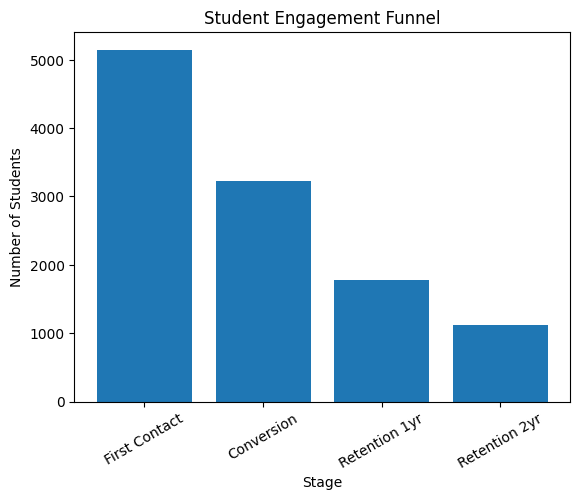

In [7]:
import matplotlib.pyplot as plt

# Convert percentages back to numeric for plotting
plot_df = pd.DataFrame({
    "Stage": ["First Contact", "Conversion", "Retention 1yr", "Retention 2yr"],
    "Value": [
        total_students,
        conversion_rate * total_students,
        retention_1_rate * total_students,
        retention_2_rate * total_students
    ]
})

plt.figure()
plt.bar(plot_df["Stage"], plot_df["Value"])
plt.title("Student Engagement Funnel")
plt.xlabel("Stage")
plt.ylabel("Number of Students")
plt.xticks(rotation=30)
plt.show()


In [15]:
df["year"] = df["year"].astype(int)
df["student_id"] = df["person_id"]

term_order = {"WN":1, "FA":2}
df["term_num"] = df["term_season"].map(term_order)

df = df.sort_values(["student_id", "year", "term_num"])

<Figure size 640x480 with 0 Axes>

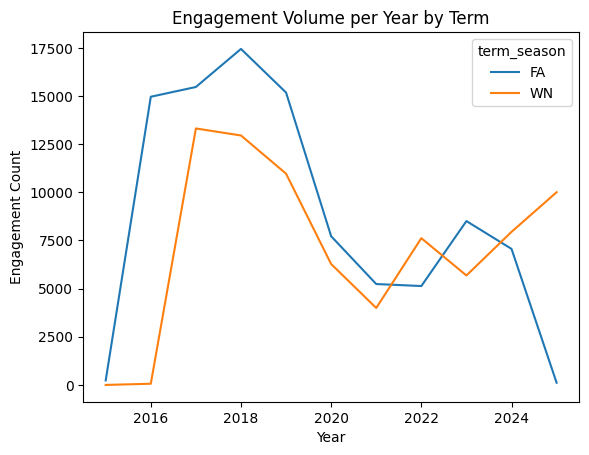

In [21]:
# Normalize casing first (important)
df["term_season"] = df["term_season"].str.upper()

# Fix inconsistencies
df["term_season"] = df["term_season"].replace({
    "SS": "SP"
})

df_fw = df[df["term_season"].isin(["FA", "WN"])]

engagements_by_year_term = (
    df_fw.groupby(["year", "term_season"])["experience_id"]
    .count()
    .reset_index(name="engagement_count")
)

pivot_engagements = engagements_by_year_term.pivot(
    index="year",
    columns="term_season",
    values="engagement_count"
).fillna(0)

plt.figure()
pivot_engagements.plot()
plt.title("Engagement Volume per Year by Term")
plt.xlabel("Year")
plt.ylabel("Engagement Count")
plt.show()

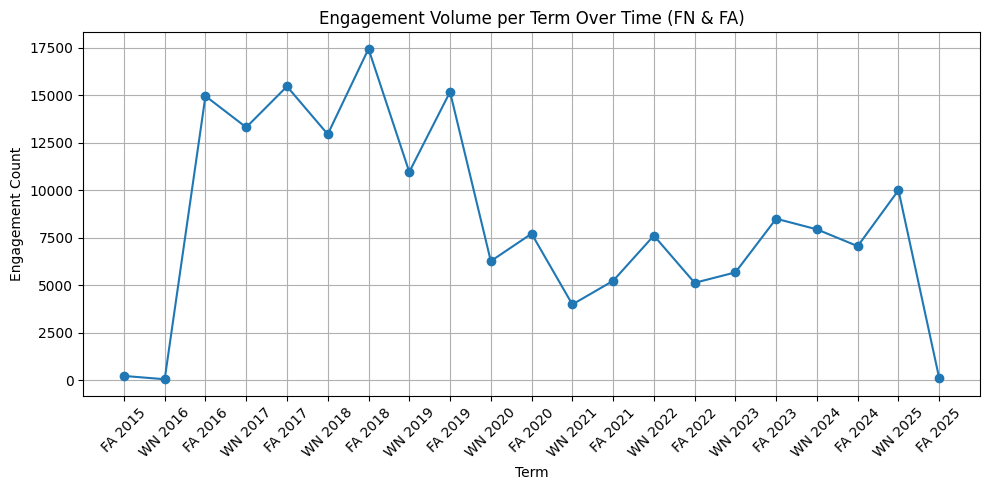

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Standardize term labels ---
df["term_season"] = df["term_season"].str.upper()
df["term_season"] = df["term_season"].replace({"SS": "SP"})

# Keep only FA and WN
df_fw = df[df["term_season"].isin(["FA", "WN"])]

# Map terms to numeric for chronological order
term_order = {"WN": 1, "FA": 2}  # WN = FN
df_fw["term_num"] = df_fw["term_season"].map(term_order)

# Create a numeric timeline: each term in each year is a point
df_fw["time_index"] = df_fw["year"] * 10 + df_fw["term_num"]

# Group by this timeline
engagements_by_time = (
    df_fw.groupby("time_index")["experience_id"]
    .count()
    .reset_index(name="engagement_count")
)

# For x-axis labels, convert WN → FN
def format_term_label(row):
    term_label = "WN" if row["time_index"] % 10 == 1 else "FA"
    year = row["time_index"] // 10
    return f"{term_label} {int(year)}"

engagements_by_time["term_label"] = engagements_by_time.apply(format_term_label, axis=1)

# Sort by timeline
engagements_by_time = engagements_by_time.sort_values("time_index")

# --- Plot ---
plt.figure(figsize=(10,5))
plt.plot(engagements_by_time["term_label"], engagements_by_time["engagement_count"], marker="o")
plt.xticks(rotation=45)
plt.title("Engagement Volume per Term Over Time (FN & FA)")
plt.xlabel("Term")
plt.ylabel("Engagement Count")
plt.grid(True)
plt.tight_layout()
plt.show()

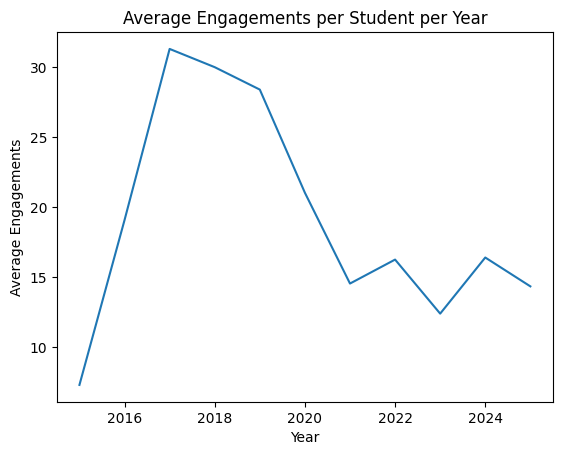

In [27]:
engagements_per_student_year = (
    df.groupby(["year", "student_id"])["experience_id"]
    .count()
    .reset_index(name="engagements")
)

avg_engagements_per_year = (
    engagements_per_student_year.groupby("year")["engagements"].mean()
)

plt.figure()
avg_engagements_per_year.plot()
plt.title("Average Engagements per Student per Year")
plt.xlabel("Year")
plt.ylabel("Average Engagements")
plt.show()

In [46]:
# revise the columns for registrar_class_year_clean

# Define mapping
def clean_class_year(x):
    x = str(x).strip()
    
    # Remove specific unneeded entries
    if x in ["Retiree", "Staff", "Faculty", "unknown role"]:
        return None  # will drop later
    
    # Alumni / Alumnus
    if x.lower().startswith("alumn"):
        return "Alumnus"
    
    # Graduate related entries
    if "grad" in x.lower() or "master" in x.lower() or "doctorate" in x.lower() or "cand" in x.lower():
        return "Graduate"
    
    # Undergraduate Special
    if "undergraduate special" in x.lower() or "uspec" in x.lower() or "ncf" in x.lower():
        return "Undergraduate Special"
    
    # Core undergraduate years
    if "freshman" in x.lower():
        return "Freshman"
    if "sophomore" in x.lower():
        return "Sophomore"
    if "junior" in x.lower():
        return "Junior"
    if "senior" in x.lower():
        return "Senior"
    
    return None  # anything else gets dropped

# Apply to df
df["registrar_class_year_clean"] = df["registrar_class_year"].apply(clean_class_year)

# Drop rows that didn't match (irrelevant categories)
df_clean = df.dropna(subset=["registrar_class_year_clean"])

# Summarize counts
category_counts = df_clean["registrar_class_year_clean"].value_counts()
print(category_counts)

registrar_class_year_clean
Alumnus                  54409
Graduate                 44874
Senior                   23181
Junior                   15704
Sophomore                12005
Freshman                  8717
Undergraduate Special        1
Name: count, dtype: int64


<Figure size 1000x600 with 0 Axes>

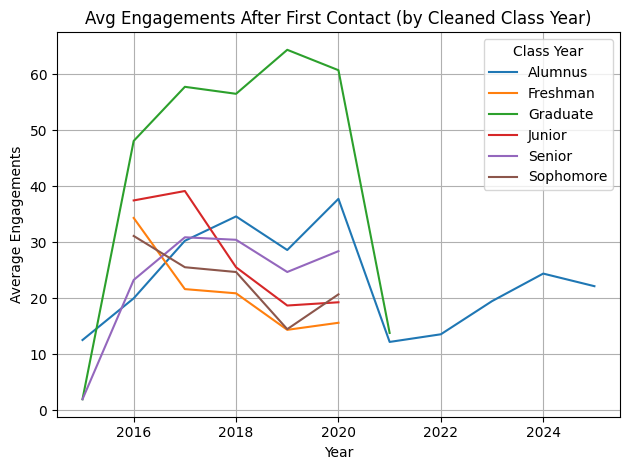

In [47]:
import matplotlib.pyplot as plt

# --- Step 1: Find first engagement per student ---
first_engagement = (
    df.groupby("student_id")[["year", "term_num"]]
    .min()
    .reset_index()
    .rename(columns={"year": "first_year", "term_num": "first_term"})
)

# --- Step 2: Merge first engagement info back ---
df2 = df.merge(first_engagement, on="student_id")

# --- Step 3: Keep only engagements after first contact ---
df_post = df2[
    (df2["year"] > df2["first_year"]) |
    ((df2["year"] == df2["first_year"]) & (df2["term_num"] > df2["first_term"]))
]

# --- Step 4: Count post-first-contact engagements per student per year, using cleaned class year ---
post_counts = (
    df_post.groupby(["student_id", "year", "registrar_class_year_clean"])["experience_id"]
    .count()
    .reset_index(name="engagements")
)

# --- Step 5: Compute average engagements per year by cleaned class year ---
avg_post_by_class = (
    post_counts.groupby(["year", "registrar_class_year_clean"])["engagements"]
    .mean()
    .unstack()
)

# --- Step 6: Plot ---
plt.figure(figsize=(10,6))
avg_post_by_class.plot()
plt.title("Avg Engagements After First Contact (by Cleaned Class Year)")
plt.xlabel("Year")
plt.ylabel("Average Engagements")
plt.xticks(rotation=0)
plt.legend(title="Class Year")
plt.grid(True)
plt.tight_layout()
plt.show()

/Users/ethanpeterson/Documents/club_projects/mdc/smtd/myenv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


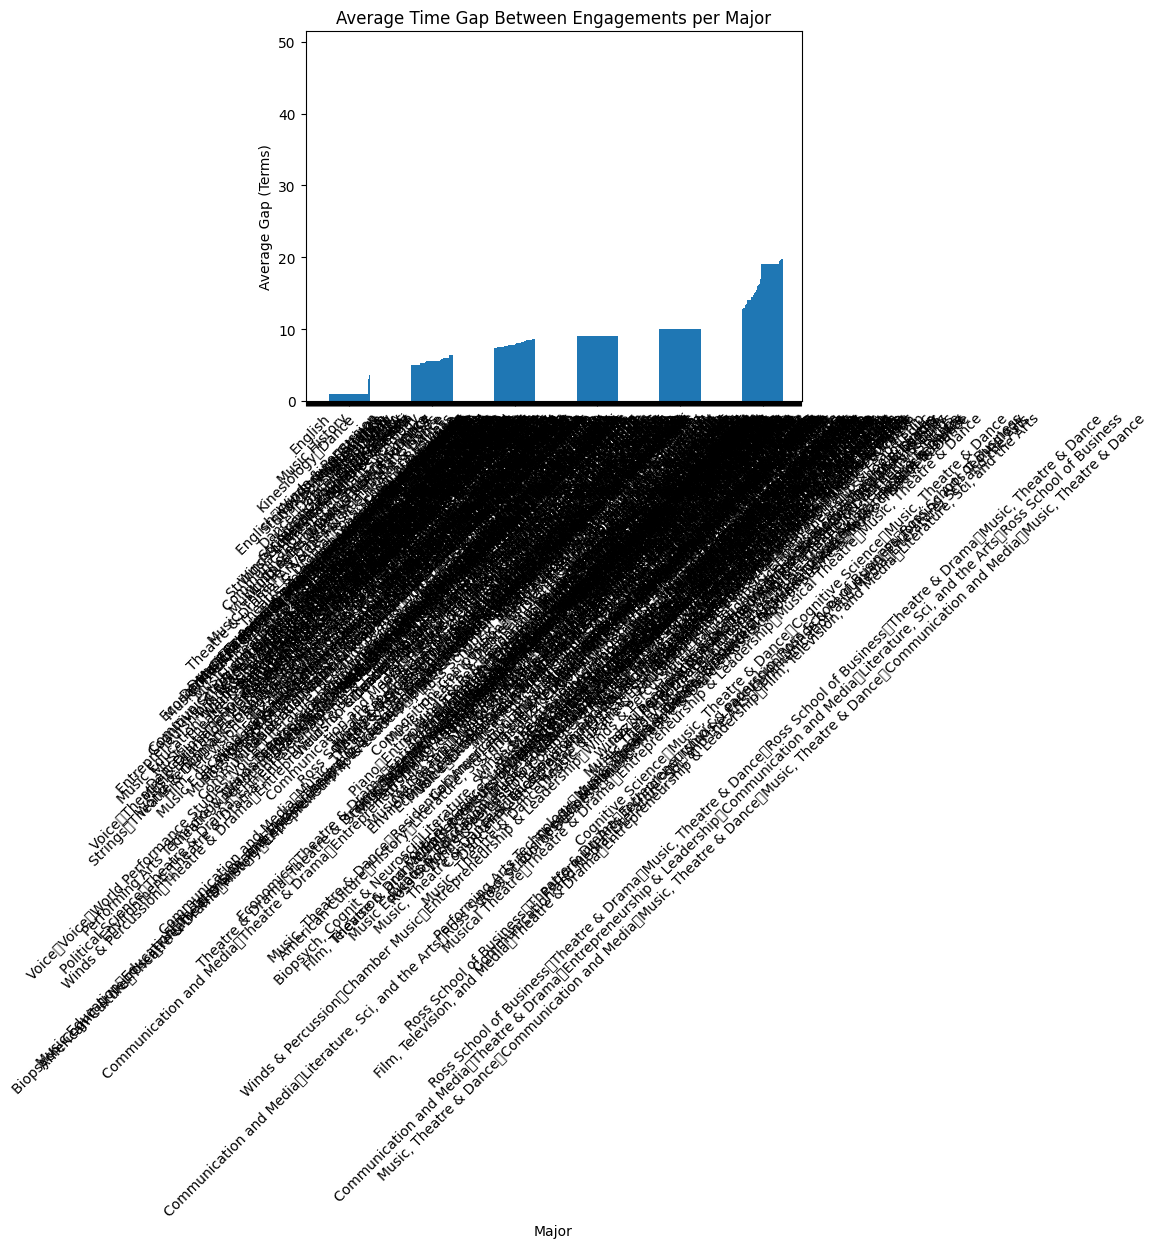

In [19]:
df["time_index"] = df["year"] * 10 + df["term_num"]

df["prev_time"] = df.groupby("student_id")["time_index"].shift(1)
df["gap"] = df["time_index"] - df["prev_time"]

df_gaps = df.dropna(subset=["gap"])
df_gaps = df_gaps[df_gaps["gap"] > 0]

avg_gap_by_major = (
    df_gaps.groupby("major_department")["gap"]
    .mean()
    .sort_values()
)

plt.figure()
avg_gap_by_major.plot(kind="bar")
plt.title("Average Time Gap Between Engagements per Major")
plt.xlabel("Major")
plt.ylabel("Average Gap (Terms)")
plt.xticks(rotation=45)
plt.show()